In [ ]:
!pip install ultralytics roboflow onnx


import os
import shutil
import torch
import glob
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display
from ultralytics import YOLO
from roboflow import Roboflow
from google.colab import drive

drive.mount('/content/drive')

#DRIVE_ROOT = '######'

if not os.path.exists(DRIVE_ROOT):
    os.makedirs(DRIVE_ROOT)
    print(f"Creating working directory: {DRIVE_ROOT}")
else:
    print(f"Working directory already exists: {DRIVE_ROOT}")

os.chdir(DRIVE_ROOT)
print(f"Current working directory switched to: {os.getcwd()}")

if not hasattr(torch, '_custom_patch_applied'):
    _original_load = torch.load
    def patched_load(*args, **kwargs):
        kwargs['weights_only'] = False
        return _original_load(*args, **kwargs)
    torch.load = patched_load
    torch._custom_patch_applied = True

try:
    !pip install roboflow

    from roboflow import Roboflow
    #rf = Roboflow(api_key="######")
    #project = rf.workspace("#######").project("######")
    #version = project.version(6)
    dataset = version.download("yolov8")

    data_yaml_path = os.path.join(dataset.location, 'data.yaml')
    print(f"Dataset ready, config file located in Drive: {data_yaml_path}")

except Exception as e:
    print(f"Dataset download error: {e}")

Mounted at /content/drive
Working directory already exists: /content/drive/MyDrive/E5/EAI/Projet/30_bright_train
Current working directory switched to: /content/drive/MyDrive/E5/EAI/Projet/30_bright_train
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Proj_Navi_auto-6 in yolov8:: 100%|██████████| 1301/1301 [00:10<00:00, 126.50it/s]

Dataset ready, config file located in Drive: /content/drive/MyDrive/E5/EAI/Projet/30_bright_train/Proj_Navi_auto-6/data.yaml


In [3]:
SELECT_DEVICE = 0

if SELECT_DEVICE == 0 and not torch.cuda.is_available():
    print("Warning: GPU not detected, forcing switch to CPU mode.")
    SELECT_DEVICE = 'cpu'
else:
    print(f"Current device used: {SELECT_DEVICE} ({torch.cuda.get_device_name(0) if SELECT_DEVICE==0 else 'CPU'})")

model = YOLO('yolov8n-seg.pt')

project_dir = DRIVE_ROOT
experiment_name = 'exp_128px'

TRAIN_ARGS = {
    'data': data_yaml_path,
    'epochs': 100,
    'patience': 20,
    'imgsz': 128,
    'batch': 16,
    'project': project_dir,
    'name': experiment_name,
    'exist_ok': True,

    'device': SELECT_DEVICE,

    'hsv_h': 0.0,
    'hsv_s': 0.0,
    'hsv_v': 0.0,
    'mosaic': 1.0,
}

print(f"Starting training... Logs will be written directly to: {os.path.join(DRIVE_ROOT, project_dir, experiment_name)}")

# Start training
results = model.train(**TRAIN_ARGS)

actual_save_dir = str(model.trainer.save_dir)
print(f"\nTraining finished. Results saved at: {actual_save_dir}")

best_pt_path = os.path.join(actual_save_dir, 'weights', 'best.pt')

if os.path.exists(best_pt_path):
    best_model = YOLO(best_pt_path)
    best_model.export(format='onnx', imgsz=[128, 128], dynamic=False, opset=11)

    best_onnx_path = best_pt_path.replace('.pt', '.onnx')

    print(f"\nCopying model files to Drive Root: {DRIVE_ROOT} ...")

    target_pt = os.path.join(DRIVE_ROOT, 'best.pt')
    target_onnx = os.path.join(DRIVE_ROOT, 'best.onnx')

    # Copy files
    shutil.copy(best_pt_path, target_pt)
    print(f"PT Model saved to: {target_pt}")

    if os.path.exists(best_onnx_path):
        shutil.copy(best_onnx_path, target_onnx)
        print(f"ONNX Model saved to: {target_onnx}")
    else:
        print("ONNX generation failed or file not found.")

else:
    print(f"Weights file not found at: {best_pt_path}")

Current device used: 0 (Tesla T4)
Starting training... Logs will be written directly to: /content/drive/MyDrive/E5/EAI/Projet/30_bright_train/exp_128px
Ultralytics 8.4.9 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/E5/EAI/Projet/30_bright_train/Proj_Navi_auto-6/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.0, hsv_s=0.0, hsv_v=0.0, imgsz=128, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0,

Analyzing results from: /content/drive/MyDrive/E5/EAI/Projet/30_bright_train/exp_128px
Best mAP50-95 (Mask): 0.6463 (Epoch 57)


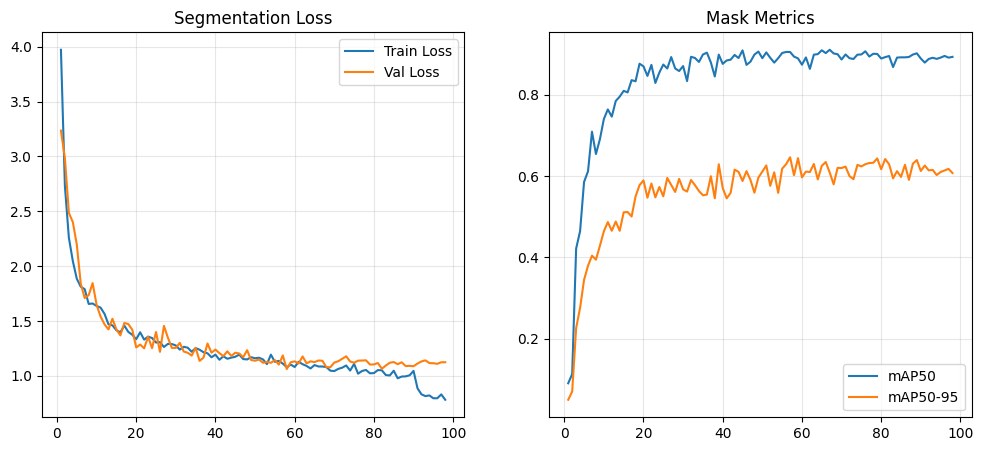

Displaying: results.png


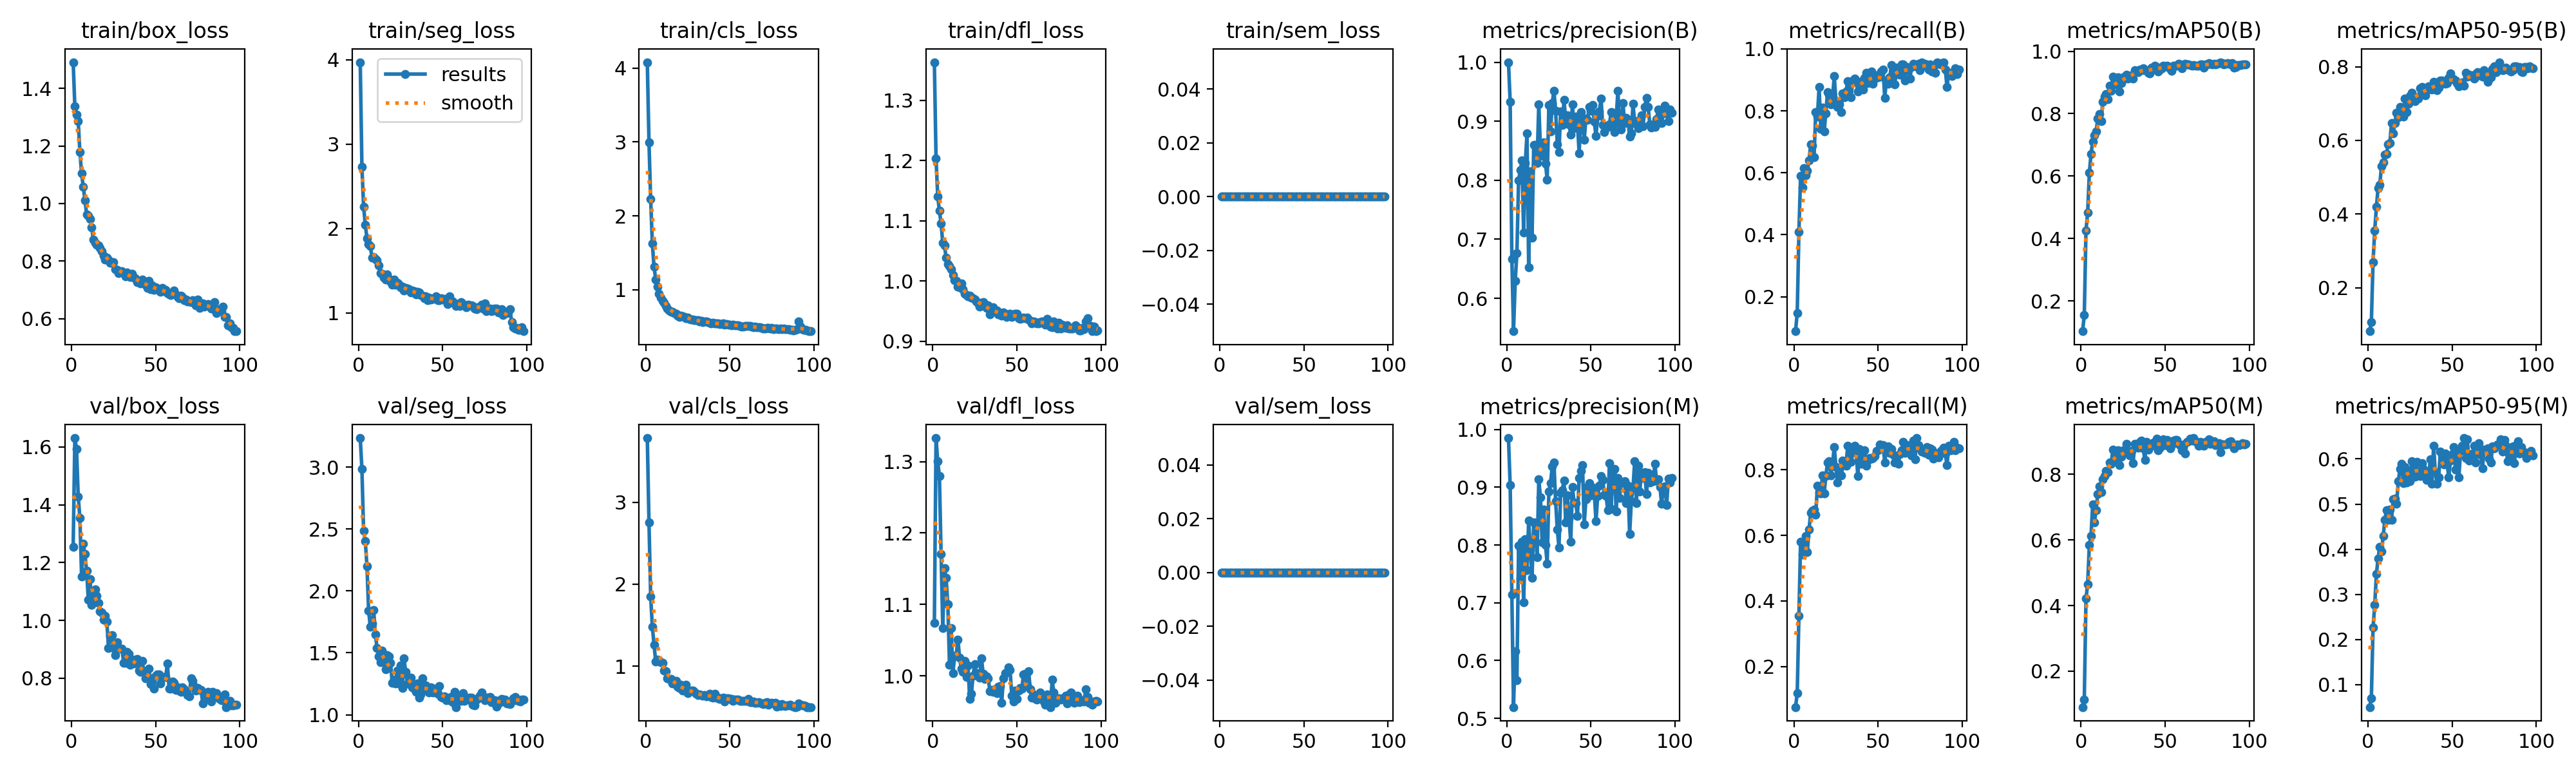

Displaying: confusion_matrix_normalized.png


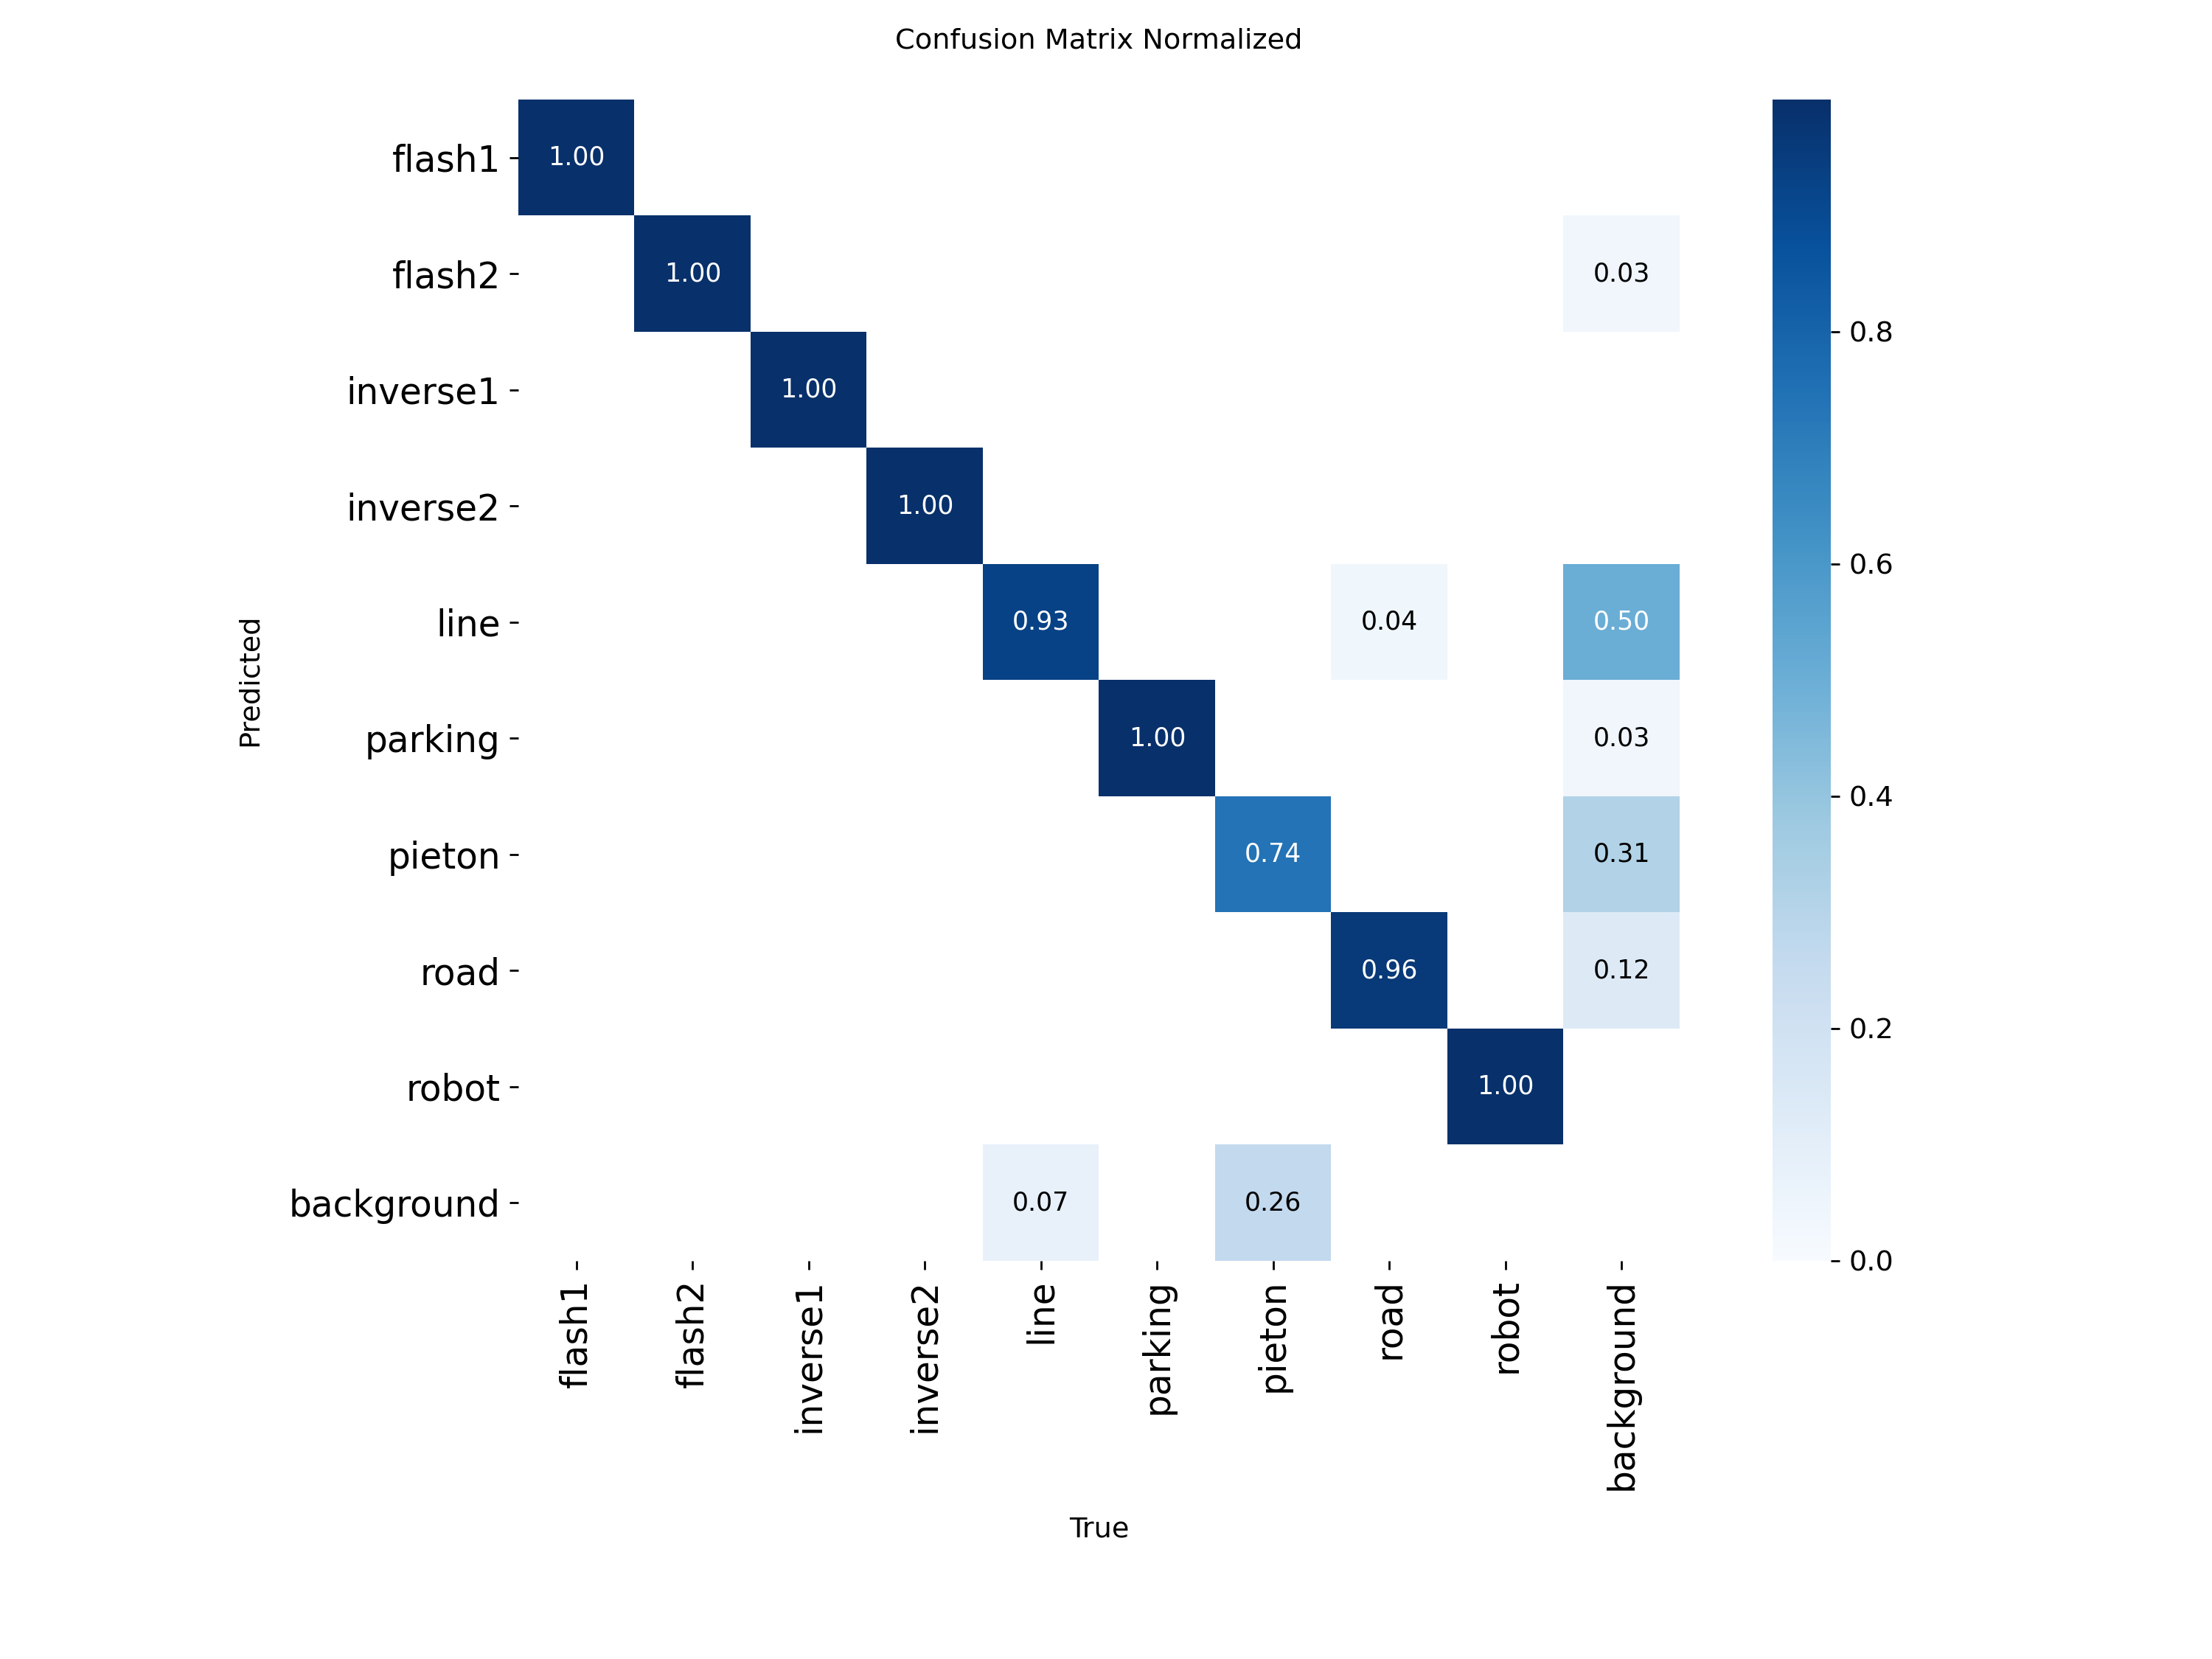

Displaying: labels.jpg


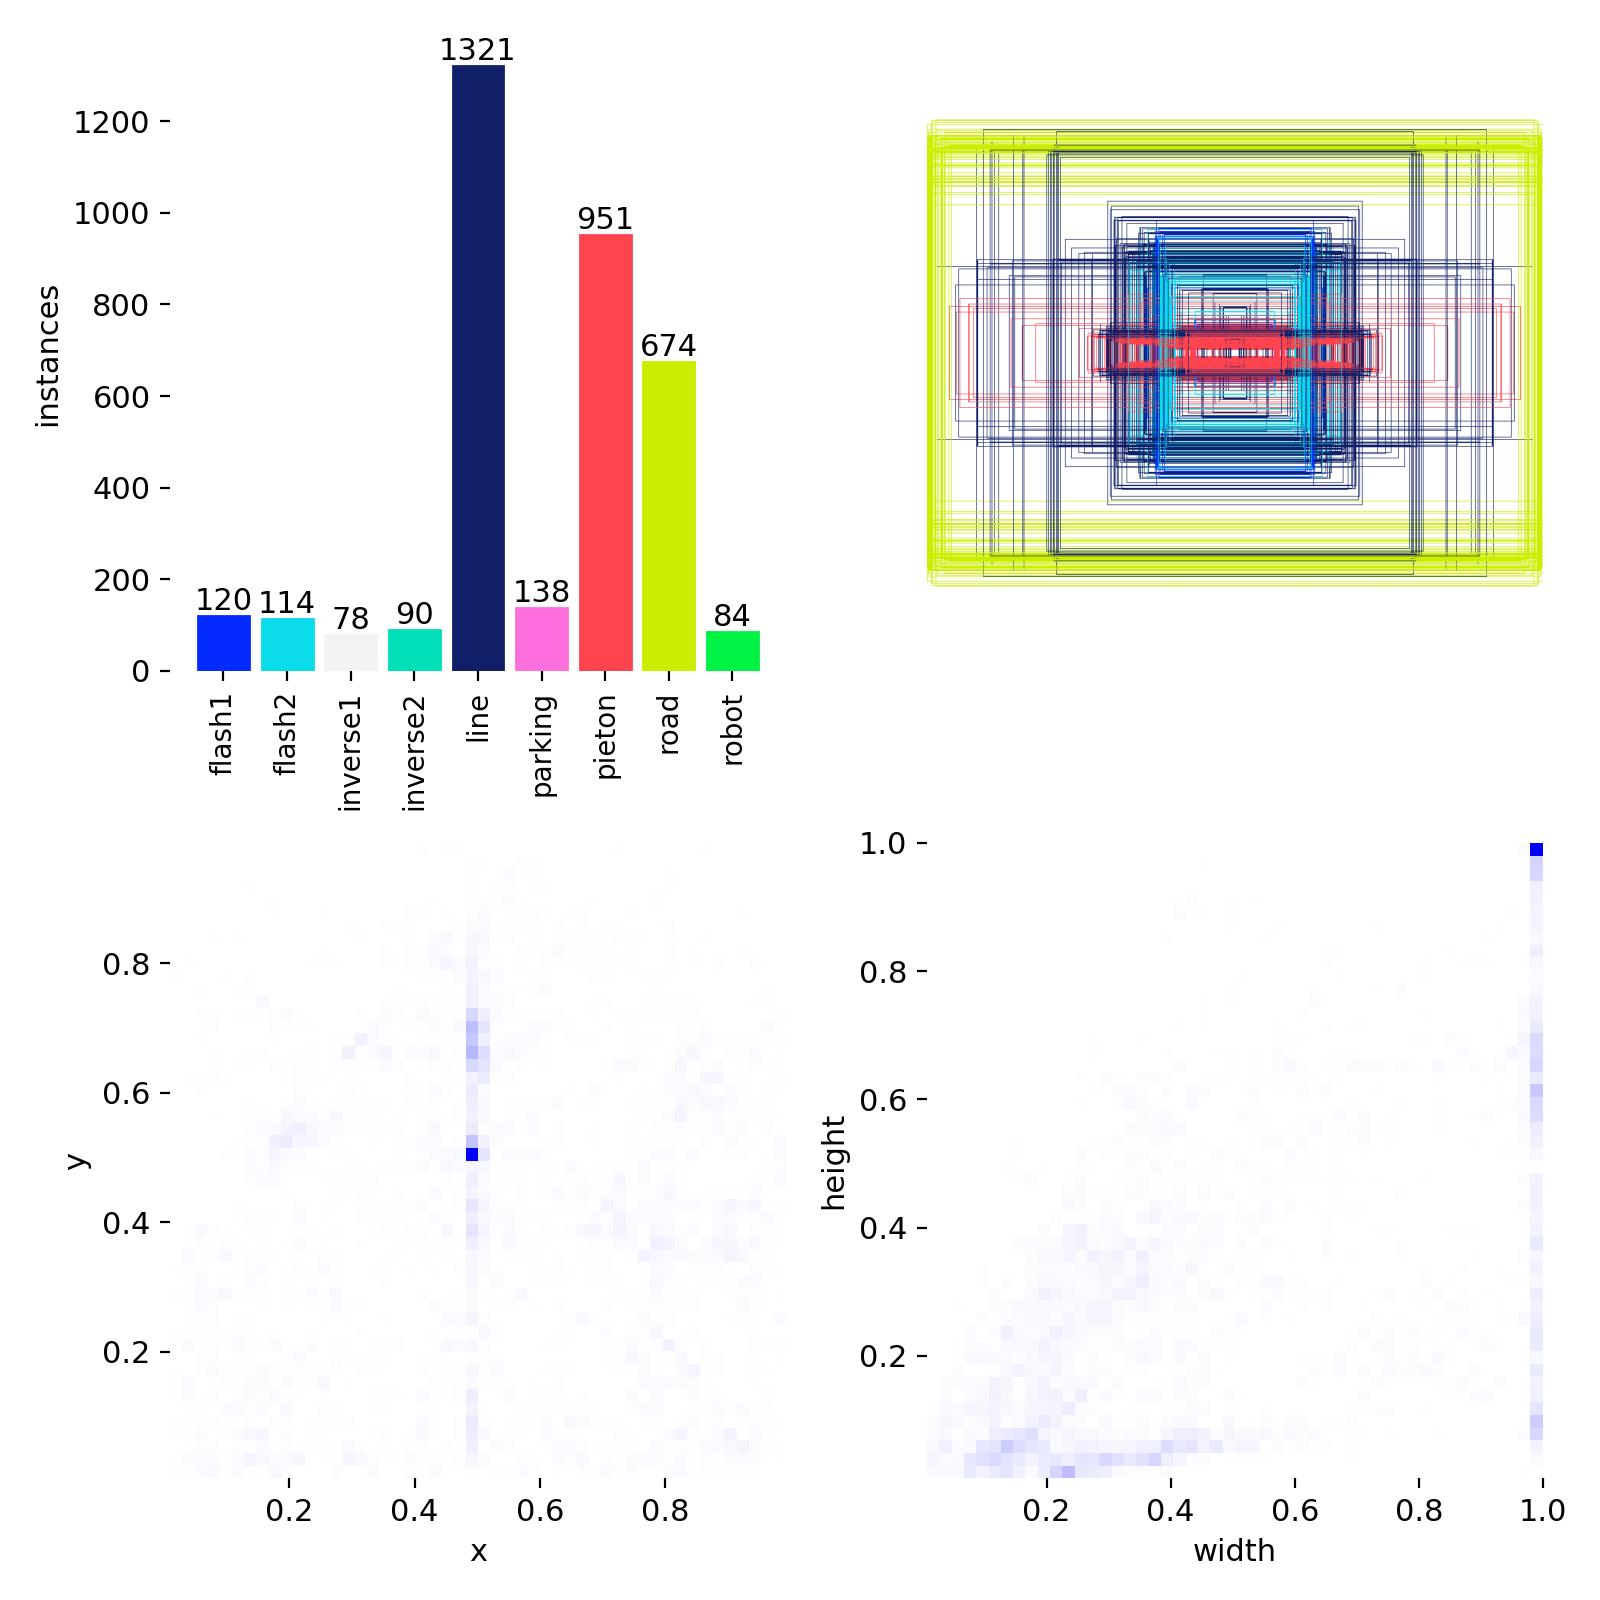


[Validation Results]


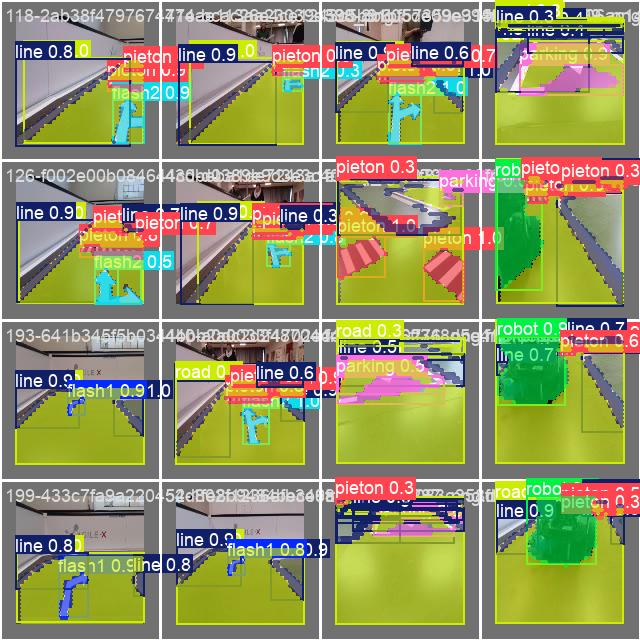

In [4]:
possible_dirs = [
    os.path.join(DRIVE_ROOT, 'exp_128px'),
    os.path.join(DRIVE_ROOT, 'exp_128px'),
]

run_dir = None
for d in possible_dirs:
    if os.path.exists(os.path.join(d, 'results.csv')):
        run_dir = d
        break

if run_dir:
    print(f"Analyzing results from: {run_dir}")
    csv_path = os.path.join(run_dir, 'results.csv')

    df = pd.read_csv(csv_path)
    df.columns = df.columns.str.strip()

    metric_key = 'metrics/mAP50-95(M)'
    if metric_key in df.columns:
        best_row = df.loc[df[metric_key].idxmax()]
        print(f"Best mAP50-95 (Mask): {best_row[metric_key]:.4f} (Epoch {int(best_row['epoch'])})")

        plt.figure(figsize=(12, 5))
        plt.subplot(1, 2, 1)
        plt.plot(df['epoch'], df.get('train/seg_loss'), label='Train Loss')
        plt.plot(df['epoch'], df.get('val/seg_loss'), label='Val Loss')
        plt.title('Segmentation Loss')
        plt.legend()
        plt.grid(True, alpha=0.3)

        plt.subplot(1, 2, 2)
        plt.plot(df['epoch'], df.get('metrics/mAP50(M)'), label='mAP50')
        plt.plot(df['epoch'], df.get(metric_key), label='mAP50-95')
        plt.title('Mask Metrics')
        plt.legend()
        plt.grid(True, alpha=0.3)

        plt.show()

    target_images = ['results.png', 'confusion_matrix_normalized.png', 'labels.jpg']

    for img_name in target_images:
        img_path = os.path.join(run_dir, img_name)
        if os.path.exists(img_path):
            print(f"Displaying: {img_name}")
            display(Image(img_path, width=800))
        else:
            print(f"Warning: {img_name} not found in {run_dir}")

    print("\n[Validation Results]")
    val_preds = glob.glob(os.path.join(run_dir, 'val_batch*_pred.jpg'))
    if val_preds:
        for img in val_preds[:2]:
            display(Image(img, width=800))
    else:
        print("Prediction images not found.")
else:
    print(f"Could not find results.csv in anticipated directories.\nPlease check the 'runs' folder in your Drive manually.")